# M3 & M4 - Conformal Prediction

---
## Section 1 - Setup

In [1]:
%pip install -q -r requirements.txt


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# ── Environment ───────────────────────────────────────────────────────────────
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# ── Datasets ──────────────────────────────────────────────────────────────────
DATASETS = {
    "SKAB": {
        "npy_dir":     "npy_skab",
        "hf_dataset":  "skab-anomaly-detection",
        "window_size": 30,
        "n_features":  8,
    },
    "NAB": {
        "npy_dir":     "npy_nab",
        "hf_dataset":  "nab-anomaly-detection",
        "window_size": 50,
        "n_features":  1,
    },
}

# ── Conformal Prediction ───────────────────────────────────────────────────────
ALPHA = 0.05        # significance level → FPR ≤ 5% guaranteed on calibration set

# ── M3 HP: Dense AE + CP (best from M1, dropout_p fixed at 0.0 → deterministic)
M3_HP = {
    "SKAB": {"latent_dim": 32, "lr": 0.001},
    "NAB":  {"latent_dim": 32, "lr": 0.002},
}

# ── M4 HP: LSTM AE + CP (best from M2, dropout_p fixed at 0.0 → deterministic)
M4_HP = {
    "SKAB": {"latent_dim": 32, "lr": 0.001, "hidden_dim": 64},
    "NAB":  {"latent_dim": 64, "lr": 0.001, "hidden_dim": 64},
}
LSTM_HIDDEN_DIM = 64   # fallback if ds not in M4_HP

# ── Training ──────────────────────────────────────────────────────────────────
EPOCHS     = 150
PATIENCE   = 20
BATCH_SIZE = 256

# ── Outputs ───────────────────────────────────────────────────────────────────
import os
RESULTS_FILE = "outputs/baseline_results.json"
OUTPUT_DIR   = "outputs"
CKPT_DIR     = "models"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CKPT_DIR,   exist_ok=True)

# ── HF Hub ────────────────────────────────────────────────────────────────────
PUSH_TO_HUB = True

# ── W&B ───────────────────────────────────────────────────────────────────────
USE_WANDB     = True
WANDB_PROJECT = "iot-ad-cp"


In [3]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    f1_score, precision_recall_curve,
)
from huggingface_hub import HfApi, create_repo

# ── Credentials ────────────────────────────────────────────────────────────────
def _secret(key):
    """Read a Colab secret by name (takes exactly 1 arg)."""
    from google.colab import userdata
    return userdata.get(key)

if IN_COLAB:
    HF_USERNAME  = _secret("HF_USERNAME")
    HF_TOKEN     = _secret("HF_TOKEN")
    WANDB_KEY    = _secret("WANDB_API_KEY")
    WANDB_ENTITY = _secret("WANDB_ENTITY")
    if USE_WANDB:
        import wandb
        if WANDB_KEY:
            wandb.login(key=WANDB_KEY, relogin=True)
        else:
            print("⚠ WANDB_API_KEY not set in Colab secrets - W&B offline")
            os.environ["WANDB_MODE"] = "offline"
else:
    from dotenv import load_dotenv
    load_dotenv()
    HF_USERNAME  = os.getenv("HF_USERNAME")
    HF_TOKEN     = os.getenv("HF_TOKEN")
    WANDB_KEY    = os.getenv("WANDB_API_KEY", "")
    WANDB_ENTITY = os.getenv("WANDB_ENTITY", "")
    if USE_WANDB:
        import wandb
        if WANDB_KEY:
            wandb.login(key=WANDB_KEY, relogin=True)
        else:
            print("⚠ WANDB_API_KEY not set in .env - running offline")
            os.environ["WANDB_MODE"] = "offline"

MODEL_REPO_ID = f"{HF_USERNAME}/iot-ad-models"
api = HfApi()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"HF repo: {MODEL_REPO_ID}")


⚠ WANDB_API_KEY not set in .env - running offline
Device : cuda
HF repo: None/iot-ad-models


In [4]:
try:
    create_repo(
        repo_id   = MODEL_REPO_ID,
        repo_type = "model",
        token     = HF_TOKEN,
        private   = False,
        exist_ok  = True,
    )
    print(f"HF model repo ready: https://huggingface.co/{MODEL_REPO_ID}")
except Exception as e:
    print(f"HF repo check skipped: {e}")


HF repo check skipped: Client error '401 Unauthorized' for url 'https://huggingface.co/api/repos/create' (Request ID: Root=1-6a35908c-3133c2f1132f8cfe348c9290;cad48833-0a8a-4187-80ce-b85bc5f43612)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/401

Invalid username or password.


---
## Section 2 - Data Loading

In [5]:
def _load_local(ds_name, cfg):
    """Load npy arrays from local disk. Returns dict or None."""
    npy_dir = cfg["npy_dir"]
    if not os.path.isdir(npy_dir):
        print(f"  Local '{npy_dir}' not found.")
        return None
    arrays = {}
    for name in ["X_train", "X_val", "X_test", "y_train", "y_val", "y_test"]:
        path = os.path.join(npy_dir, f"{name}.npy")
        if not os.path.exists(path):
            print(f"  Missing {path}.")
            return None
        arrays[name] = np.load(path)
    print(f"  Loaded {ds_name} from local disk - "
          f"train {arrays['X_train'].shape}, val {arrays['X_val'].shape}, "
          f"test {arrays['X_test'].shape}")
    return arrays


def _load_from_hub(ds_name, cfg):
    """Load windowed arrays from HF Hub. Returns dict or None.

    Dataset structure: splits 'train' / 'validation' / 'test',
    columns feature_0 .. feature_{n-1} (each a window-length list) + 'label'.
    """
    from datasets import load_dataset as hf_load
    repo = f"{HF_USERNAME}/{cfg['hf_dataset']}"
    print(f"  Fetching {ds_name} from HF Hub: {repo} ...")
    try:
        ds = hf_load(repo)
    except Exception as e:
        print(f"  HF Hub load failed for {ds_name}: {e}")
        return None

    n_feat = cfg["n_features"]

    def to_np(split):
        X = np.stack(
            [np.array(split[f"feature_{i}"]) for i in range(n_feat)], axis=-1
        ).astype(np.float32)
        y = np.array(split["label"], dtype=np.int8)
        return X, y

    try:
        X_train, y_train = to_np(ds["train"])
        X_val,   y_val   = to_np(ds["validation"])
        X_test,  y_test  = to_np(ds["test"])
    except Exception as e:
        print(f"  Failed to parse HF Hub data for {ds_name}: {e}")
        return None

    print(f"  Loaded {ds_name} from HF Hub - "
          f"train {X_train.shape}, val {X_val.shape}, test {X_test.shape}")
    return dict(
        X_train=X_train, X_val=X_val, X_test=X_test,
        y_train=y_train, y_val=y_val, y_test=y_test,
    )


data = {}
for ds_name, cfg in DATASETS.items():
    print(f"\n{'='*55}\n{ds_name}")
    arr = _load_local(ds_name, cfg)
    if arr is None:
        print(f"  Local npy not found - fetching from HF Hub ...")
        arr = _load_from_hub(ds_name, cfg)
    if arr is not None:
        data[ds_name] = arr
        print(f"  y_test anomaly rate: "
              f"{arr['y_test'].mean():.3%}  ({arr['y_test'].sum()} / {len(arr['y_test'])})")
    else:
        print(f"  ERROR: could not load {ds_name}.")

print(f"\nDatasets loaded: {list(data.keys())}")


SKAB
  Loaded SKAB from local disk - train (23588, 30, 8), val (3345, 30, 8), test (19786, 30, 8)
  y_test anomaly rate: 67.507%  (13357 / 19786)

NAB
  Loaded NAB from local disk - train (229577, 50, 1), val (30354, 50, 1), test (97101, 50, 1)
  y_test anomaly rate: 35.555%  (34524 / 97101)

Datasets loaded: ['SKAB', 'NAB']


---
## Section 3 - Model Architectures

In [6]:
class DenseAE(nn.Module):
    """Dense autoencoder. With dropout_p=0 + model.eval() → fully deterministic."""

    def __init__(self, input_dim: int, latent_dim: int = 32,
                 dropout_p: float = 0.0):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(), nn.Dropout(dropout_p),
            nn.Linear(128, 64),        nn.ReLU(), nn.Dropout(dropout_p),
            nn.Linear(64, latent_dim), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64), nn.ReLU(), nn.Dropout(dropout_p),
            nn.Linear(64, 128),        nn.ReLU(), nn.Dropout(dropout_p),
            nn.Linear(128, input_dim), nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.decoder(self.encoder(x))


In [7]:
class LSTMAE(nn.Module):
    """LSTM autoencoder. With dropout_p=0 + model.eval() → fully deterministic."""

    def __init__(self, n_features: int, hidden_dim: int = 64,
                 latent_dim: int = 32, dropout_p: float = 0.0):
        super().__init__()
        self.window_size = None  # set at first forward pass

        self.enc_lstm = nn.LSTM(n_features, hidden_dim, batch_first=True)
        self.enc_drop = nn.Dropout(dropout_p)
        self.enc_fc   = nn.Linear(hidden_dim, latent_dim)

        self.dec_fc   = nn.Linear(latent_dim, hidden_dim)
        self.dec_drop = nn.Dropout(dropout_p)
        self.dec_lstm = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.dec_out  = nn.Sequential(nn.Linear(hidden_dim, n_features), nn.Sigmoid())

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.window_size is None:
            self.window_size = x.shape[1]
        _, (h_n, _) = self.enc_lstm(x)
        z = self.enc_fc(self.enc_drop(h_n.squeeze(0)))
        d = self.dec_drop(self.dec_fc(z))
        d_rep, _ = self.dec_lstm(d.unsqueeze(1).repeat(1, self.window_size, 1))
        return self.dec_out(d_rep)


---
## Section 4 - Training (Deterministic)

In [8]:
def push_checkpoint(api, model, filename, model_repo_id, hf_token):
    """Save model state locally; push to HF Hub if enabled."""
    local_path = os.path.join(CKPT_DIR, filename)
    torch.save(model.state_dict(), local_path)
    if not PUSH_TO_HUB:
        return
    try:
        api.upload_file(
            path_or_fileobj = local_path,
            path_in_repo    = f"checkpoints/{filename}",
            repo_id         = model_repo_id,
            repo_type       = "model",
            token           = hf_token,
        )
    except Exception as e:
        print(f"  HF push failed: {e}")


def train_det(model, X_train, X_val, run_label, is_lstm=False, wandb_run=None):
    """Train a deterministic autoencoder with early stopping.

    Parameters
    ----------
    is_lstm : bool - if True input stays 3-D; if False it is flattened to 2-D
    Returns : (model, train_losses, val_losses, best_val_loss)
    """
    def _prep(X):
        t = torch.from_numpy(X).float()
        return t if is_lstm else t.reshape(len(t), -1)

    t_dl = DataLoader(TensorDataset(_prep(X_train)), batch_size=BATCH_SIZE, shuffle=True)
    v_dl = DataLoader(TensorDataset(_prep(X_val)),   batch_size=BATCH_SIZE)
    opt  = torch.optim.Adam(model.parameters(), lr=
                            (M4_HP if is_lstm else M3_HP).get(run_label, {}).get("lr", 1e-3))
    crit = nn.MSELoss()

    best_val, best_state, patience_ctr = float("inf"), None, 0
    train_losses, val_losses = [], []

    for epoch in range(EPOCHS):
        model.train()
        t_loss = 0.0
        for (xb,) in t_dl:
            xb = xb.to(device)
            loss = crit(model(xb), xb)
            opt.zero_grad(); loss.backward(); opt.step()
            t_loss += loss.item() * len(xb)
        t_loss /= len(X_train)
        train_losses.append(t_loss)

        model.eval()
        with torch.no_grad():
            v_loss = sum(
                crit(xb.to(device), model(xb.to(device))).item() * len(xb)
                for (xb,) in v_dl
            ) / len(X_val)
        val_losses.append(v_loss)

        if (epoch + 1) % 20 == 0 or epoch == 0:
            print(f"  [{run_label}] ep {epoch+1:>4}/{EPOCHS}  "
                  f"train={t_loss:.6f}  val={v_loss:.6f}")

        if v_loss < best_val - 1e-6:
            best_val, best_state, patience_ctr = (
                v_loss, {k: v.clone() for k, v in model.state_dict().items()}, 0)
        else:
            patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"  [{run_label}] Early stop at epoch {epoch+1}  best_val={best_val:.6f}")
            break

        if wandb_run is not None:
            wandb_run.log({"train_loss": t_loss, "val_loss": v_loss, "epoch": epoch+1})

    model.load_state_dict(best_state)
    return model, train_losses, val_losses, best_val


---
## Section 5 - Conformal Prediction Functions

In [9]:
def _recon_errors(model, X, is_lstm=False, batch_size=512):
    """Per-window MSE under model.eval(). Shape: (n_windows,)."""
    model.eval()
    t = torch.from_numpy(X).float()
    if not is_lstm:
        t = t.reshape(len(t), -1)
    errors = []
    with torch.no_grad():
        for (xb,) in DataLoader(TensorDataset(t), batch_size=batch_size):
            xb = xb.to(device)
            if is_lstm:
                err = ((xb - model(xb)) ** 2).mean(dim=(1, 2))
            else:
                err = ((xb - model(xb)) ** 2).mean(dim=1)
            errors.append(err.cpu().numpy())
    return np.concatenate(errors)


def cp_threshold(cal_scores, alpha=ALPHA):
    """Inductive CP threshold with finite-sample correction."""
    n = len(cal_scores)
    q_level = min(np.ceil((n + 1) * (1 - alpha)) / n, 1.0)
    return float(np.quantile(cal_scores, q_level))


def cp_pvalues(test_scores, cal_scores):
    """Conformal p-value for each test point: fraction of cal scores >= test score."""
    n = len(cal_scores)
    # Vectorised: for each test score, count how many cal scores are >= it
    # Shape trick: (n_cal, 1) >= (1, n_test) → sum over axis=0
    return (np.sum(cal_scores[:, None] >= test_scores[None, :], axis=0) + 1) / (n + 1)


def compute_metrics_cp(y_true, test_scores, cal_scores, alpha=ALPHA):
    """Standard detection metrics + CP-specific metrics."""
    thr      = cp_threshold(cal_scores, alpha)
    p_values = cp_pvalues(test_scores, cal_scores)

    auc_pr = float(average_precision_score(y_true, test_scores))
    auroc  = float(roc_auc_score(y_true, test_scores))
    y_pred = (test_scores >= thr).astype(int)
    f1     = float(f1_score(y_true, y_pred, zero_division=0))

    # auroc_unc: AUROC using 1−p as anomaly score (rank-equivalent to test_scores)
    auroc_unc = float(roc_auc_score(y_true, 1 - p_values))

    # mean_unc: empirical coverage on NORMAL class (should be >= 1-alpha = 0.95)
    normal_mask = (y_true == 0)
    mean_unc    = float(np.mean(p_values[normal_mask] >= alpha))  # empirical coverage

    return dict(
        auc_pr    = round(auc_pr,    4),
        auroc     = round(auroc,     4),
        f1        = round(f1,        4),
        threshold = float(thr),
        auroc_unc = round(auroc_unc, 4),
        mean_unc  = round(mean_unc,  4),   # empirical coverage (>=0.95 = good)
        alpha     = alpha,
        empirical_coverage = round(mean_unc, 4),
    )


---
## Section 6 - Train M3 (Dense AE + CP)

In [10]:
m3_results = {}

for ds_name, cfg in DATASETS.items():
    if ds_name not in data:
        print(f"Skipping {ds_name} - data not loaded.")
        continue

    arr    = data[ds_name]
    X_train, X_val, X_test = arr["X_train"], arr["X_val"], arr["X_test"]
    y_test = arr["y_test"]
    hp     = M3_HP[ds_name]

    input_dim = cfg["window_size"] * cfg["n_features"]
    print(f"\n{'='*65}")
    print(f"  M3 - Dense AE + CP  |  {ds_name}  "
          f"|  latent_dim={hp['latent_dim']}  lr={hp['lr']:.0e}")
    print(f"{'='*65}")

    # ── W&B run ───────────────────────────────────────────────────────────────
    wb_run = None
    if USE_WANDB:
        try:
            wb_run = wandb.init(
                project = WANDB_PROJECT,
                entity  = WANDB_ENTITY or None,
                name    = f"M3_{ds_name}",
                config  = dict(method="Dense_AE_CP", dataset=ds_name,
                               latent_dim=hp["latent_dim"], lr=hp["lr"],
                               alpha=ALPHA),
                reinit  = True,
            )
        except Exception as e:
            print(f"  ⚠ W&B init failed: {e}")
            wb_run = None

    # ── Train ─────────────────────────────────────────────────────────────────
    model = DenseAE(input_dim=input_dim, latent_dim=hp["latent_dim"],
                    dropout_p=0.0).to(device)
    model, t_losses, v_losses, best_val = train_det(
        model, X_train, X_val, run_label=ds_name, is_lstm=False, wandb_run=wb_run)
    print(f"  Training done.  best_val={best_val:.6f}  epochs={len(t_losses)}")

    # ── CP calibration ────────────────────────────────────────────────────────
    cal_scores  = _recon_errors(model, X_val,  is_lstm=False)
    test_scores = _recon_errors(model, X_test, is_lstm=False)
    thr         = cp_threshold(cal_scores, ALPHA)
    print(f"  CP threshold (α={ALPHA}): {thr:.6f}  "
          f"(val 95th pct: {np.percentile(cal_scores, 95):.6f})")

    # ── Metrics ───────────────────────────────────────────────────────────────
    metrics = compute_metrics_cp(y_test, test_scores, cal_scores, ALPHA)
    print(f"  AUC-PR={metrics['auc_pr']:.4f}  AUROC={metrics['auroc']:.4f}  "
          f"F1={metrics['f1']:.4f}  coverage={metrics['empirical_coverage']:.4f}")

    if wb_run is not None:
        try:
            wb_run.log({**metrics, "best_val_loss": best_val, "n_epochs": len(t_losses)})
            wb_run.finish()
        except Exception:
            pass

    # ── Save checkpoint ───────────────────────────────────────────────────────
    ckpt_name = f"m3_dense_cp_{ds_name.lower()}_best.pt"
    push_checkpoint(api, model, ckpt_name, MODEL_REPO_ID, HF_TOKEN)
    print(f"  Checkpoint → {CKPT_DIR}/{ckpt_name}")

    m3_results[ds_name] = dict(
        hp           = hp,
        metrics      = metrics,
        train_losses = t_losses,
        val_losses   = v_losses,
        cal_scores   = cal_scores,
        test_scores  = test_scores,
        p_values     = cp_pvalues(test_scores, cal_scores),
    )

print("\n✓ M3 complete.")



  M3 - Dense AE + CP  |  SKAB  |  latent_dim=32  lr=1e-03


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


  [SKAB] ep    1/150  train=0.034662  val=0.016742
  [SKAB] ep   20/150  train=0.008682  val=0.007108
  [SKAB] ep   40/150  train=0.007763  val=0.006355
  [SKAB] ep   60/150  train=0.006994  val=0.005798
  [SKAB] ep   80/150  train=0.006664  val=0.005451
  [SKAB] ep  100/150  train=0.006053  val=0.005034
  [SKAB] ep  120/150  train=0.005879  val=0.004869
  [SKAB] ep  140/150  train=0.005578  val=0.004690
  Training done.  best_val=0.004590  epochs=150
  CP threshold (α=0.05): 0.006452  (val 95th pct: 0.006441)
  AUC-PR=0.7904  AUROC=0.5947  F1=0.4011  coverage=0.9159


alpha,▁
auc_pr,▁
auroc,▁
auroc_unc,▁
best_val_loss,▁
empirical_coverage,▁
epoch,▁▁▁▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇█
f1,▁
mean_unc,▁
n_epochs,▁
+3,...


  HF push failed: 401 Client Error. (Request ID: Root=1-6a3590b7-77dbdf07687eb35c526e0890;d0875535-5061-4882-a2b2-00dc9992cc24)

Repository Not Found for url: https://huggingface.co/api/models/None/iot-ad-models/preupload/main.
Please make sure you specified the correct `repo_id` and `repo_type`.
If you are trying to access a private or gated repo, make sure you are authenticated and your token has the required permissions.
For more details, see https://huggingface.co/docs/huggingface_hub/authentication
Invalid username or password.
Note: Creating a commit assumes that the repo already exists on the Huggingface Hub. Please use `create_repo` if it's not the case.
  Checkpoint → models/m3_dense_cp_skab_best.pt

  M3 - Dense AE + CP  |  NAB  |  latent_dim=32  lr=2e-03


  [NAB] ep    1/150  train=0.013600  val=0.007768
  [NAB] ep   20/150  train=0.002092  val=0.001984
  [NAB] ep   40/150  train=0.001841  val=0.001706
  [NAB] ep   60/150  train=0.001802  val=0.001690
  [NAB] ep   80/150  train=0.001719  val=0.001589
  [NAB] ep  100/150  train=0.001683  val=0.001578
  [NAB] ep  120/150  train=0.001668  val=0.001552
  [NAB] ep  140/150  train=0.001644  val=0.001523
  Training done.  best_val=0.001514  epochs=150
  CP threshold (α=0.05): 0.005491  (val 95th pct: 0.005488)
  AUC-PR=0.4649  AUROC=0.5983  F1=0.3165  coverage=0.9220


alpha,▁
auc_pr,▁
auroc,▁
auroc_unc,▁
best_val_loss,▁
empirical_coverage,▁
epoch,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▅▅▅▆▆▆▆▆▆▇▇▇▇█████
f1,▁
mean_unc,▁
n_epochs,▁
+3,...


  HF push failed: 401 Client Error. (Request ID: Root=1-6a35925e-460d58904ea3b99c653dc4f6;10c30d7c-dc3d-4af3-a21d-27adc4a75d11)

Repository Not Found for url: https://huggingface.co/api/models/None/iot-ad-models/preupload/main.
Please make sure you specified the correct `repo_id` and `repo_type`.
If you are trying to access a private or gated repo, make sure you are authenticated and your token has the required permissions.
For more details, see https://huggingface.co/docs/huggingface_hub/authentication
Invalid username or password.
Note: Creating a commit assumes that the repo already exists on the Huggingface Hub. Please use `create_repo` if it's not the case.
  Checkpoint → models/m3_dense_cp_nab_best.pt

✓ M3 complete.


---
## Section 7 - Train M4 (LSTM AE + CP)

In [11]:
m4_results = {}

for ds_name, cfg in DATASETS.items():
    if ds_name not in data:
        print(f"Skipping {ds_name} - data not loaded.")
        continue

    arr    = data[ds_name]
    X_train, X_val, X_test = arr["X_train"], arr["X_val"], arr["X_test"]
    y_test = arr["y_test"]
    hp     = M4_HP[ds_name]
    h_dim  = hp.get("hidden_dim", LSTM_HIDDEN_DIM)

    print(f"\n{'='*65}")
    print(f"  M4 - LSTM AE + CP  |  {ds_name}  "
          f"|  latent_dim={hp['latent_dim']}  hidden={h_dim}  lr={hp['lr']:.0e}")
    print(f"{'='*65}")

    # ── W&B run ───────────────────────────────────────────────────────────────
    wb_run = None
    if USE_WANDB:
        try:
            wb_run = wandb.init(
                project = WANDB_PROJECT,
                entity  = WANDB_ENTITY or None,
                name    = f"M4_{ds_name}",
                config  = dict(method="LSTM_AE_CP", dataset=ds_name,
                               latent_dim=hp["latent_dim"], hidden_dim=h_dim,
                               lr=hp["lr"], alpha=ALPHA),
                reinit  = True,
            )
        except Exception as e:
            print(f"  ⚠ W&B init failed: {e}")
            wb_run = None

    # ── Train ─────────────────────────────────────────────────────────────────
    model = LSTMAE(n_features=cfg["n_features"], hidden_dim=h_dim,
                   latent_dim=hp["latent_dim"], dropout_p=0.0).to(device)
    model, t_losses, v_losses, best_val = train_det(
        model, X_train, X_val, run_label=ds_name, is_lstm=True, wandb_run=wb_run)
    print(f"  Training done.  best_val={best_val:.6f}  epochs={len(t_losses)}")

    # ── CP calibration ────────────────────────────────────────────────────────
    cal_scores  = _recon_errors(model, X_val,  is_lstm=True)
    test_scores = _recon_errors(model, X_test, is_lstm=True)
    thr         = cp_threshold(cal_scores, ALPHA)
    print(f"  CP threshold (α={ALPHA}): {thr:.6f}  "
          f"(val 95th pct: {np.percentile(cal_scores, 95):.6f})")

    # ── Metrics ───────────────────────────────────────────────────────────────
    metrics = compute_metrics_cp(y_test, test_scores, cal_scores, ALPHA)
    print(f"  AUC-PR={metrics['auc_pr']:.4f}  AUROC={metrics['auroc']:.4f}  "
          f"F1={metrics['f1']:.4f}  coverage={metrics['empirical_coverage']:.4f}")

    if wb_run is not None:
        try:
            wb_run.log({**metrics, "best_val_loss": best_val, "n_epochs": len(t_losses)})
            wb_run.finish()
        except Exception:
            pass

    # ── Save checkpoint ───────────────────────────────────────────────────────
    ckpt_name = f"m4_lstm_cp_{ds_name.lower()}_best.pt"
    push_checkpoint(api, model, ckpt_name, MODEL_REPO_ID, HF_TOKEN)
    print(f"  Checkpoint → {CKPT_DIR}/{ckpt_name}")

    m4_results[ds_name] = dict(
        hp           = hp,
        metrics      = metrics,
        train_losses = t_losses,
        val_losses   = v_losses,
        cal_scores   = cal_scores,
        test_scores  = test_scores,
        p_values     = cp_pvalues(test_scores, cal_scores),
    )

print("\n✓ M4 complete.")



  M4 - LSTM AE + CP  |  SKAB  |  latent_dim=32  hidden=64  lr=1e-03


  [SKAB] ep    1/150  train=0.031364  val=0.023252
  [SKAB] ep   20/150  train=0.009062  val=0.007978
  [SKAB] ep   40/150  train=0.008736  val=0.007729
  [SKAB] ep   60/150  train=0.008715  val=0.007477
  [SKAB] ep   80/150  train=0.008588  val=0.007298
  [SKAB] ep  100/150  train=0.008492  val=0.007307
  [SKAB] Early stop at epoch 107  best_val=0.007209
  Training done.  best_val=0.007209  epochs=107
  CP threshold (α=0.05): 0.009704  (val 95th pct: 0.009702)
  AUC-PR=0.7631  AUROC=0.5458  F1=0.4106  coverage=0.8622


alpha,▁
auc_pr,▁
auroc,▁
auroc_unc,▁
best_val_loss,▁
empirical_coverage,▁
epoch,▁▁▁▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇███
f1,▁
mean_unc,▁
n_epochs,▁
+3,...


  HF push failed: 401 Client Error. (Request ID: Root=1-6a359298-1f0e519f4dae308d6fee6186;f7bc83f9-bab0-4bc7-80a2-8f6f578cc892)

Repository Not Found for url: https://huggingface.co/api/models/None/iot-ad-models/preupload/main.
Please make sure you specified the correct `repo_id` and `repo_type`.
If you are trying to access a private or gated repo, make sure you are authenticated and your token has the required permissions.
For more details, see https://huggingface.co/docs/huggingface_hub/authentication
Invalid username or password.
Note: Creating a commit assumes that the repo already exists on the Huggingface Hub. Please use `create_repo` if it's not the case.
  Checkpoint → models/m4_lstm_cp_skab_best.pt

  M4 - LSTM AE + CP  |  NAB  |  latent_dim=64  hidden=64  lr=1e-03


  [NAB] ep    1/150  train=0.017790  val=0.011850
  [NAB] ep   20/150  train=0.004067  val=0.004712
  [NAB] ep   40/150  train=0.003192  val=0.002854
  [NAB] ep   60/150  train=0.002501  val=0.002338
  [NAB] ep   80/150  train=0.002304  val=0.002009
  [NAB] ep  100/150  train=0.001827  val=0.001812
  [NAB] ep  120/150  train=0.001810  val=0.001586
  [NAB] ep  140/150  train=0.001527  val=0.001429
  Training done.  best_val=0.001364  epochs=150
  CP threshold (α=0.05): 0.004782  (val 95th pct: 0.004780)
  AUC-PR=0.4686  AUROC=0.6014  F1=0.3193  coverage=0.9223


alpha,▁
auc_pr,▁
auroc,▁
auroc_unc,▁
best_val_loss,▁
empirical_coverage,▁
epoch,▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
f1,▁
mean_unc,▁
n_epochs,▁
+3,...


  HF push failed: 401 Client Error. (Request ID: Root=1-6a3594d5-1b7421636b6538906d69ce37;bdb51676-1609-4d1a-bbfc-3c3b5381ac8c)

Repository Not Found for url: https://huggingface.co/api/models/None/iot-ad-models/preupload/main.
Please make sure you specified the correct `repo_id` and `repo_type`.
If you are trying to access a private or gated repo, make sure you are authenticated and your token has the required permissions.
For more details, see https://huggingface.co/docs/huggingface_hub/authentication
Invalid username or password.
Note: Creating a commit assumes that the repo already exists on the Huggingface Hub. Please use `create_repo` if it's not the case.
  Checkpoint → models/m4_lstm_cp_nab_best.pt

✓ M4 complete.


---
## Section 8 - Comparison Table

In [12]:
# Load prior results for comparison
try:
    with open(RESULTS_FILE) as f:
        saved = json.load(f)
    print(f"Loaded {RESULTS_FILE}")
except FileNotFoundError:
    saved = {}
    print("WARNING: baseline_results.json not found - prior columns empty.")

rows = []
method_order = [
    ("B3_denseae",    "B3 - Dense AE (det.)"),
    ("M1_dense_mcd",  "M1 - Dense AE + MCD"),
    ("M2_lstm_mcd",   "M2 - LSTM AE + MCD"),
    ("M3_dense_cp",   "M3 - Dense AE + CP"),
    ("M4_lstm_cp",    "M4 - LSTM AE + CP"),
]

for ds_name in ["SKAB", "NAB"]:
    for key, label in method_order:
        if key in ("M3_dense_cp", "M4_lstm_cp"):
            src = m3_results if key == "M3_dense_cp" else m4_results
            m   = src.get(ds_name, {}).get("metrics", {})
        else:
            m = saved.get(ds_name, {}).get(key, {}).get("metrics", {})
        rows.append({
            "Dataset":    ds_name,
            "Method":     label,
            "AUC-PR ↑":   m.get("auc_pr",    float("nan")),
            "AUROC ↑":    m.get("auroc",     float("nan")),
            "F1 ↑":       m.get("f1",        float("nan")),
            "AUROC(unc)↑":m.get("auroc_unc", float("nan")),
            "Coverage":   m.get("mean_unc",  float("nan")),
        })

df = pd.DataFrame(rows)
for ds_name in ["SKAB", "NAB"]:
    sub = df[df["Dataset"] == ds_name].drop(columns="Dataset").reset_index(drop=True)
    print(f"\n{'='*85}")
    print(f"  {ds_name}")
    print(f"{'='*85}")
    print(sub.to_string(index=False))


Loaded outputs/baseline_results.json

  SKAB
              Method  AUC-PR ↑  AUROC ↑   F1 ↑  AUROC(unc)↑  Coverage
B3 - Dense AE (det.)    0.7960   0.6105 0.3914          NaN       NaN
 M1 - Dense AE + MCD       NaN      NaN    NaN          NaN       NaN
  M2 - LSTM AE + MCD       NaN      NaN    NaN          NaN       NaN
  M3 - Dense AE + CP    0.7904   0.5947 0.4011       0.5944    0.9159
   M4 - LSTM AE + CP    0.7631   0.5458 0.4106       0.5448    0.8622

  NAB
              Method  AUC-PR ↑  AUROC ↑   F1 ↑  AUROC(unc)↑  Coverage
B3 - Dense AE (det.)    0.4672   0.6012 0.3183          NaN       NaN
 M1 - Dense AE + MCD       NaN      NaN    NaN          NaN       NaN
  M2 - LSTM AE + MCD       NaN      NaN    NaN          NaN       NaN
  M3 - Dense AE + CP    0.4649   0.5983 0.3165       0.5985    0.9220
   M4 - LSTM AE + CP    0.4686   0.6014 0.3193       0.6016    0.9223


---
## Section 9 - Visualisations

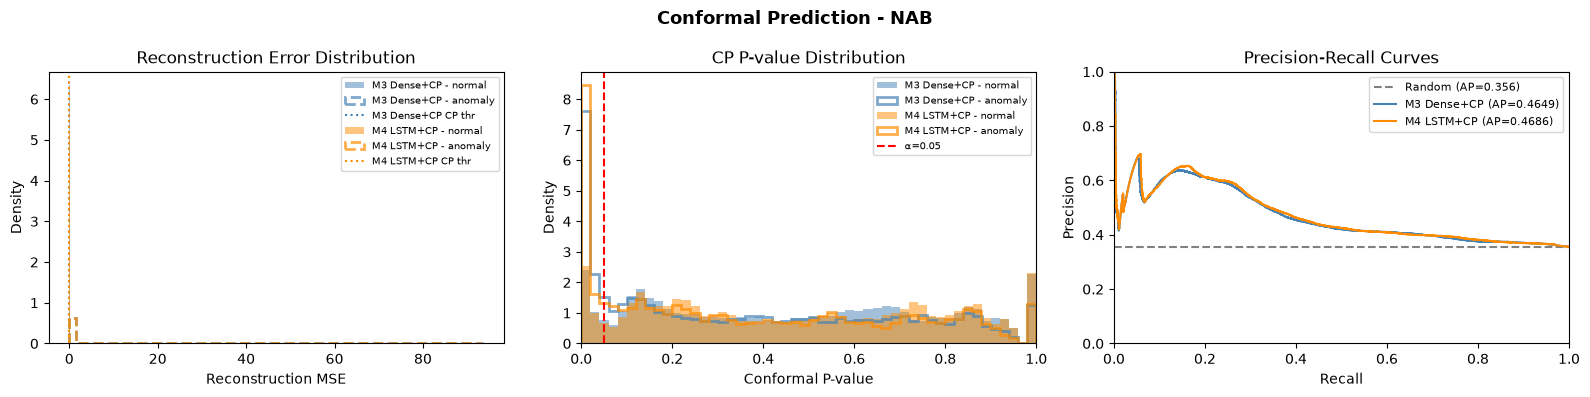

  Saved → outputs/cp_nab_analysis.png


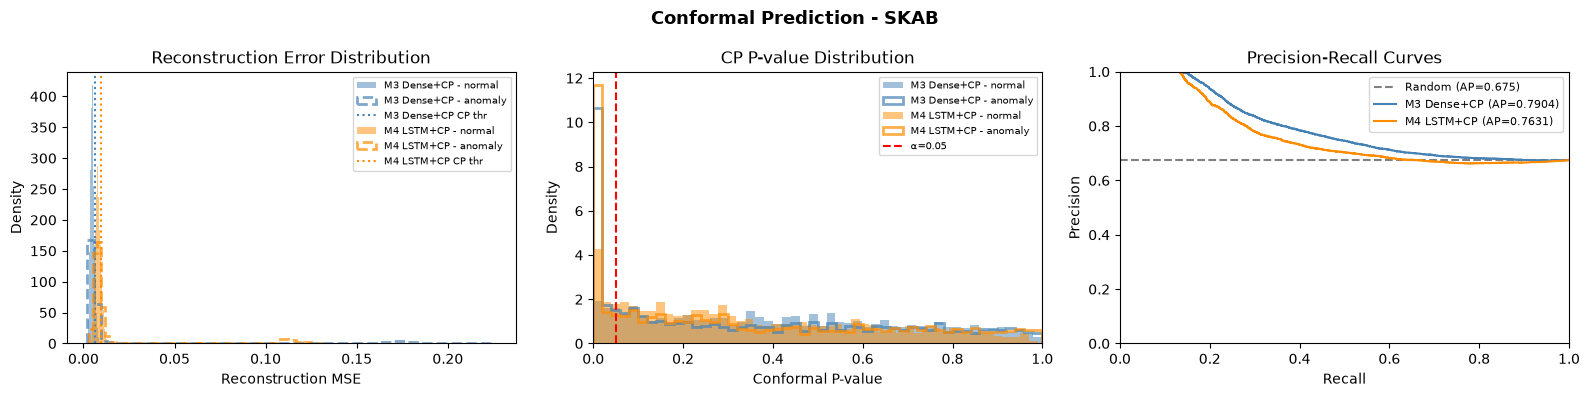

  Saved → outputs/cp_skab_analysis.png


In [13]:
warnings.filterwarnings("ignore")

for ds_name in sorted(set(list(m3_results.keys()) + list(m4_results.keys()))):
    y_test = data[ds_name]["y_test"]
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f"Conformal Prediction - {ds_name}", fontsize=13, fontweight="bold")

    # ── 1. Score distributions ────────────────────────────────────────────────
    ax = axes[0]
    ax.set_title("Reconstruction Error Distribution")
    for label, res, color in [
        ("M3 Dense+CP", m3_results.get(ds_name, {}), "steelblue"),
        ("M4 LSTM+CP",  m4_results.get(ds_name, {}), "darkorange"),
    ]:
        if not res:
            continue
        ts = res["test_scores"]
        ax.hist(ts[y_test == 0], bins=60, alpha=0.5,
                color=color, label=f"{label} - normal", density=True)
        ax.hist(ts[y_test == 1], bins=60, alpha=0.7,
                color=color, label=f"{label} - anomaly", density=True, linestyle="--",
                histtype="step", linewidth=2)
        thr = res["metrics"]["threshold"]
        ax.axvline(thr, color=color, linestyle=":", linewidth=1.5,
                   label=f"{label} CP thr")
    ax.set_xlabel("Reconstruction MSE")
    ax.set_ylabel("Density")
    ax.legend(fontsize=7)

    # ── 2. P-value distributions ──────────────────────────────────────────────
    ax = axes[1]
    ax.set_title("CP P-value Distribution")
    for label, res, color in [
        ("M3 Dense+CP", m3_results.get(ds_name, {}), "steelblue"),
        ("M4 LSTM+CP",  m4_results.get(ds_name, {}), "darkorange"),
    ]:
        if not res:
            continue
        pv = res["p_values"]
        ax.hist(pv[y_test == 0], bins=50, alpha=0.5,
                color=color, label=f"{label} - normal", density=True)
        ax.hist(pv[y_test == 1], bins=50, alpha=0.7,
                color=color, label=f"{label} - anomaly", density=True,
                histtype="step", linewidth=2)
    ax.axvline(ALPHA, color="red", linestyle="--", label=f"α={ALPHA}", linewidth=1.5)
    ax.set_xlabel("Conformal P-value")
    ax.set_ylabel("Density")
    ax.legend(fontsize=7)
    ax.set_xlim(0, 1)

    # ── 3. PR curves ──────────────────────────────────────────────────────────
    ax = axes[2]
    ax.set_title("Precision-Recall Curves")
    baseline = y_test.mean()
    ax.axhline(baseline, color="grey", linestyle="--", label=f"Random (AP={baseline:.3f})")
    for label, res, color in [
        ("M3 Dense+CP", m3_results.get(ds_name, {}), "steelblue"),
        ("M4 LSTM+CP",  m4_results.get(ds_name, {}), "darkorange"),
    ]:
        if not res:
            continue
        prec, rec, _ = precision_recall_curve(y_test, res["test_scores"])
        auc_pr = res["metrics"]["auc_pr"]
        ax.plot(rec, prec, color=color, label=f"{label} (AP={auc_pr:.4f})", linewidth=1.5)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

    plt.tight_layout()
    out_path = os.path.join(OUTPUT_DIR, f"cp_{ds_name.lower()}_analysis.png")
    plt.savefig(out_path, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"  Saved → {out_path}")


---
## Section 10 - Save Results

In [14]:
# Load existing, append M3 / M4, write back
try:
    with open(RESULTS_FILE) as f:
        all_results = json.load(f)
except FileNotFoundError:
    all_results = {}
    print("WARNING: baseline_results.json not found - creating fresh.")

for ds_name in sorted(set(list(m3_results.keys()) + list(m4_results.keys()))):
    if ds_name not in all_results:
        all_results[ds_name] = {}

    for key, results in [("M3_dense_cp", m3_results), ("M4_lstm_cp", m4_results)]:
        if ds_name not in results:
            continue
        res = results[ds_name]
        m   = res["metrics"].copy()
        # strip arrays before serialising
        m.pop("alpha",              None)
        m.pop("empirical_coverage", None)
        all_results[ds_name][key] = {
            "hp":          res["hp"],
            "metrics":     m,
            "train_losses": res["train_losses"],
            "val_losses":   res["val_losses"],
        }

with open(RESULTS_FILE, "w") as f:
    json.dump(all_results, f, indent=2)

print(f"Results saved → {RESULTS_FILE}")
for ds_name, methods in all_results.items():
    print(f"  {ds_name}: {list(methods.keys())}")


Results saved → outputs/baseline_results.json
  SKAB: ['B1_zscore', 'B2_isoforest', 'B3_denseae', 'M3_dense_cp', 'M4_lstm_cp']
  NAB: ['B1_zscore', 'B2_isoforest', 'B3_denseae', 'M3_dense_cp', 'M4_lstm_cp']


In [15]:
print("=" * 72)
print("  M3 & M4 - CONFORMAL PREDICTION  FINAL SUMMARY")
print("=" * 72)

try:
    with open(RESULTS_FILE) as f:
        saved = json.load(f)
except FileNotFoundError:
    saved = {}

for ds_name in sorted(set(list(m3_results.keys()) + list(m4_results.keys()))):
    print(f"\n  {ds_name}")
    print(f"  {'Method':<28} {'AUC-PR':>8} {'AUROC':>8} {'F1':>8} "
          f"{'Coverage':>10} {'AUROC(unc)':>12}")
    print(f"  {'─'*76}")

    for key, label, res in [
        ("B3_denseae",  "B3 Dense AE (det.)",    None),
        ("M1_dense_mcd","M1 Dense AE + MCD",      None),
        ("M3_dense_cp", "M3 Dense AE + CP  ← new", m3_results.get(ds_name)),
        ("M2_lstm_mcd", "M2 LSTM AE + MCD",       None),
        ("M4_lstm_cp",  "M4 LSTM AE + CP   ← new", m4_results.get(ds_name)),
    ]:
        if res is None:
            m = saved.get(ds_name, {}).get(key, {}).get("metrics", {})
        else:
            m = res.get("metrics", {})
        ap  = m.get("auc_pr",    float("nan"))
        ar  = m.get("auroc",     float("nan"))
        f1  = m.get("f1",        float("nan"))
        cov = m.get("mean_unc",  float("nan"))
        au  = m.get("auroc_unc", float("nan"))
        cov_str = f"{cov:.4f}" if not (isinstance(cov, float) and cov != cov) else "  -"
        print(f"  {label:<28} {ap:>8.4f} {ar:>8.4f} {f1:>8.4f} {cov_str:>10} {au:>12.4f}")

print("\n" + "=" * 72)
print(f"  Plots   → {OUTPUT_DIR}/")
print(f"  Models  → {CKPT_DIR}/")
print(f"  Results → {RESULTS_FILE}")
print("=" * 72)
print("\nNote: 'Coverage' for CP = empirical coverage on normal test samples")
print("      (should be ≥ 0.95 to validate the formal CP guarantee)")
print("      'Coverage' for MCD = mean_unc (uncertainty magnitude - different metric)")


  M3 & M4 - CONFORMAL PREDICTION  FINAL SUMMARY

  NAB
  Method                         AUC-PR    AUROC       F1   Coverage   AUROC(unc)
  ────────────────────────────────────────────────────────────────────────────
  B3 Dense AE (det.)             0.4672   0.6012   0.3183          -          nan
  M1 Dense AE + MCD                 nan      nan      nan          -          nan
  M3 Dense AE + CP  ← new        0.4649   0.5983   0.3165     0.9220       0.5985
  M2 LSTM AE + MCD                  nan      nan      nan          -          nan
  M4 LSTM AE + CP   ← new        0.4686   0.6014   0.3193     0.9223       0.6016

  SKAB
  Method                         AUC-PR    AUROC       F1   Coverage   AUROC(unc)
  ────────────────────────────────────────────────────────────────────────────
  B3 Dense AE (det.)             0.7960   0.6105   0.3914          -          nan
  M1 Dense AE + MCD                 nan      nan      nan          -          nan
  M3 Dense AE + CP  ← new        0.7904  